# Bayesian Optimization for learning the MET Efficiency Space

In [1]:
import sys
sys.path.append("..")

import uproot 
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
import scipy.stats as st
import pandas as pd

from numpy.linalg import det

from sklearn.metrics import mean_squared_error

In [2]:
f = uproot.open("../datasets/hist.root")
tree = f['tnt']

photon_pt = np.asarray(tree['a_pt'].array())
photon_eta = np.asarray(tree['a_eta'].array())
photon_phi = np.asarray(tree['a_phi'].array())

jet_pt = np.asarray(tree['j_pt'].array())
jet_eta = np.asarray(tree['j_eta'].array())
jet_phi = np.asarray(tree['j_phi'].array())

photon_threeM = []
jet_threeM = []

nevents = photon_pt.shape[0]
for i in range(nevents):
    if ((photon_pt[i] > 20) and (jet_pt[i] > 20)):
        photon_threeM.append([photon_pt[i], photon_eta[i], photon_phi[i]])
        jet_threeM.append([jet_pt[i], jet_eta[i], jet_phi[i]])
        
photon_threeM = np.asarray(photon_threeM)
jet_threeM = np.asarray(jet_threeM)

f.close()

### Efficiency of MET < 10

In [3]:
def sigmoid(X):
    return 1. / (1. + np.exp(-X))


def dsigmoid(X):
    return sigmoid(X) * (1 - sigmoid(X))

In [4]:
def Eff_MET10(photon_scale, jet_scale, photon_threeM=photon_threeM, jet_threeM=jet_threeM):
    count = 0
    for i in range(len(photon_threeM)):
        (pt_ix, eta_ix, phi_ix) = (1, 2, 3)
        a_pt = photon_threeM[i, 0] / photon_scale
        j_pt = jet_threeM[i, 0] / jet_scale
        met_x = a_pt * np.cos(photon_threeM[i, 2]) + j_pt * np.cos(jet_threeM[i, 2])
        met_y = a_pt * np.sin(photon_threeM[i, 2]) + j_pt * np.sin(jet_threeM[i, 2])
        met = np.sqrt(met_x * met_x + met_y * met_y)
        if met < 10:
            count += 1
    return count / len(photon_threeM)


def Eff_MET10_sigmoid(photon_scale, jet_scale, photon_threeM=photon_threeM, jet_threeM=jet_threeM):
    count = 0
    for i in range(len(photon_threeM)):
        (pt_ix, eta_ix, phi_ix) = (1, 2, 3)
        a_pt = photon_threeM[i, 0] / photon_scale
        j_pt = jet_threeM[i, 0] / jet_scale
        met_x = a_pt * np.cos(photon_threeM[i, 2]) + j_pt * np.cos(jet_threeM[i, 2])
        met_y = a_pt * np.sin(photon_threeM[i, 2]) + j_pt * np.sin(jet_threeM[i, 2])
        met = np.sqrt(met_x * met_x + met_y * met_y)
        count += sigmoid(-(met-10.0))
    return count / len(photon_threeM)


def dEff_MET10_sigmoid(photon_scale, jet_scale, photon_threeM=photon_threeM, jet_threeM=jet_threeM):
    count_da = 0
    count_dj = 0
    for i in range(len(photon_threeM)):
        (pt_ix, eta_ix, phi_ix) = (1, 2, 3)
        a_pt = photon_threeM[i, 0] / photon_scale
        a_phi = photon_threeM[i, 2]
        j_pt = jet_threeM[i, 0] / jet_scale
        j_phi = jet_threeM[i, 2]
        met_x = a_pt * np.cos(a_phi) + j_pt * np.cos(j_phi)
        met_y = a_pt * np.sin(a_phi) + j_pt * np.sin(j_phi)
        met = np.sqrt(met_x * met_x + met_y * met_y)
        
        dsig = -dsigmoid(-(met-10.0))
        dmet = 0.5 / met 
        # wrt photon 
        dmet_da  = -2*met_x*photon_threeM[i, 0] * np.cos(a_phi) / photon_scale**2
        dmet_da += -2*met_y*photon_threeM[i, 0] * np.sin(a_phi) / photon_scale**2
        #wrt jet 
        dmet_dj  = -2*met_x*jet_threeM[i, 0] * np.cos(j_phi) / jet_scale**2
        dmet_dj += -2*met_y*jet_threeM[i, 0] * np.sin(j_phi) / jet_scale**2

        count_da += dsig * dmet * dmet_da
        count_dj += dsig * dmet * dmet_dj
        
    return [count_da / len(photon_threeM), count_dj / len(photon_threeM)]

### Minimizing the GP uncertainty

To sample the next location, we call sample_next_location, which takes 
the arguments 
sample_next_location(expected_improvement,   
                     previous_X,  
                     previous_y,  
                     trained_gp_model,  
                     X_bounds)  
                     
This function evaluates the following loop:  
1. Select a random X sample within the bounds.   
   The random X is the initial fuess of the   
   SKlearn minimizer.   
2. Use SKlearn minimizer to minimize the   
   negative of the expected improvement.  
3. So at each iteration, we get the   
   min value of the expected improvement   
   according to SKlearn and the  
   corresponding sample location.  
4. Output the sample location corresponding   
   to the absolute minimum of the expect. improvement   
   among all iterations.   


So it looks like what we want to modify is the Expected Improvement. What does the EI do?

expected_improvement(X, -> new samples to evaluate  
                     X_sample, -> previous samples   
                     gp, -> gp trained on X_sample     
                     xi, -> exploit/explore parameter
                     maximize) -> whether to max or min. 
                     
This function:
1. Predicts mu and std based on the fitted gp. 
2. Selects the maximum y_sample so far 
3. Calculates a quantity that estimates how likely new samples are to have a larger value than the current y_sample



In [5]:
# -- training points -- # 
nu_a_train = [0.7, 1.0, 1.0, 1.0, 1.3]
nu_j_tain = [1.0, 0.7, 1.0, 1.3, 1.0]
X_train = np.vstack((nu_a_train, nu_j_tain)).T
y_train = np.array([Eff_MET10_sigmoid(nu_a_train[i], nu_j_tain[i]) for i in range(len(X_train))])
dy_train = np.array([dEff_MET10_sigmoid(nu_a_train[i], nu_j_tain[i]) for i in range(len(X_train))])

# -- testing points -- # 
res=10
X_lower = 0.5 
X_upper = 1.5
lin = np.linspace(X_lower, X_upper, res)
nu_a_test, nu_j_test = np.meshgrid(lin, lin)
X_test = np.vstack((nu_a_test.flatten(), nu_j_test.flatten())).T 
y_test = np.array([Eff_MET10_sigmoid(X_test[i][0], X_test[i][1]) for i in range(len(X_test))])


# -- True MET -- #
y_true = np.array([Eff_MET10(X_test[i][0], X_test[i][1]) for i in range(len(X_test))])


In [6]:
sys.path.append("..")
import gpder
from gpder import plot_gpr
from gpder import GPKernelDerAware, GPKernel
from gpder import GaussianProcessRegressor

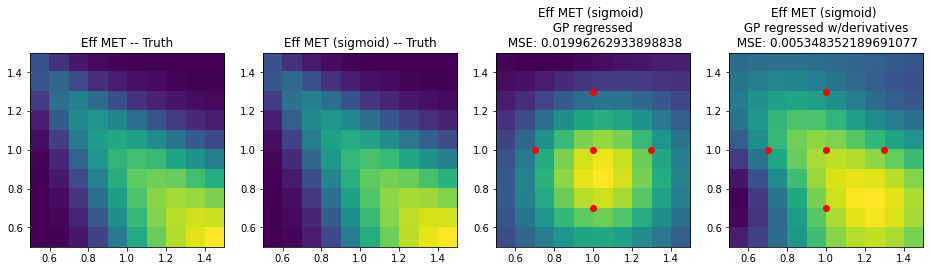

In [7]:
fig, axs = plt.subplots(1, 4, figsize=(16, 4))
ax = axs.ravel()


axs[0].set_title("Eff MET -- Truth")
axs[0].imshow(y_true.reshape(res, res), origin='upper', extent=[0.5, 1.5, 0.5, 1.5])
#axs[0].plot(X_train[:, 0], X_train[:, 1], "r.", ms=12)


axs[1].set_title("Eff MET (sigmoid) -- Truth")
axs[1].imshow(y_test.reshape(res, res), origin='upper', extent=[0.5, 1.5, 0.5, 1.5])
#axs[1].plot(X_train[:, 0], X_train[:, 1], "r.", ms=12)

# ----- Regular GP ----- #
kernel = GPKernel()
gp = GaussianProcessRegressor(kernel=kernel,
                              n_restarts_optimizer=10, 
                              random_state=123)
gp.fit(X=X_train, y=y_train)
mu, cov = gp.predict(X=X_test, return_cov=True)
mse = mean_squared_error(mu, y_true)

axs[2].set_title("Eff MET (sigmoid) \n GP regressed \n MSE: {}".format(mse))
axs[2].imshow(mu.reshape(res, res), origin='upper', extent=[0.5, 1.5, 0.5, 1.5])
axs[2].plot(X_train[:, 0], X_train[:, 1], "r.", ms=12)

# -- Now with derivatives -- #
kernel = GPKernelDerAware()
gp = GaussianProcessRegressor(kernel=kernel,
                              n_restarts_optimizer=10, 
                              random_state=123)
gp.fit(X=X_train, y=y_train, dy=dy_train)
mu, cov = gp.predict(X=X_test, return_cov=True)
mse = mean_squared_error(mu, y_true)

axs[3].set_title("Eff MET (sigmoid) \n GP regressed w/derivatives \n MSE: {}".format(mse))
axs[3].imshow(mu.reshape(res, res), origin='upper', extent=[0.5, 1.5, 0.5, 1.5])
axs[3].plot(X_train[:, 0], X_train[:, 1], "r.", ms=12)

plt.savefig("MSE")

### Now using Bayes to minimize the uncertainty

In [8]:
from gpder import BayesianOptimization_uncertainty

In [9]:
bayes = BayesianOptimization_uncertainty(fun=Eff_MET10_sigmoid,
                                         param_bounds={'photon_scale': (0.5, 1.5),
                                                       'jet_scale': (0.5, 1.5)},
                                         random_state=12)

bayes.minimize_uncertainty(params_init=X_train,
               xi=0,
               n_iters=10)

| Iter | photon_scale| jet_scale   | Target      | Uncert       |
| 0    | 0.700000    | 1.000000    | 0.187581    | 0.000000     |
| 1    | 1.000000    | 0.700000    | 0.093411    | 0.000000     |
| 2    | 1.000000    | 1.000000    | 0.373638    | 0.000000     |
| 3    | 1.000000    | 1.300000    | 0.364020    | 0.000000     |
| 4    | 1.300000    | 1.000000    | 0.272682    | 0.000000     |
| 6    | 1.500000    | 1.500000    | 0.561721    | 0.180860     |
| 7    | 0.500000    | 1.500000    | 0.000752    | 0.142339     |
| 8    | 0.500000    | 0.500000    | 0.140418    | 0.183149     |
| 9    | 1.500000    | 0.500000    | 0.000455    | 0.175566     |
| 10   | 1.000000    | 0.500000    | 0.007008    | 0.100835     |
| 11   | 1.000000    | 1.500000    | 0.296450    | 0.093923     |
| 12   | 1.500000    | 1.000000    | 0.186919    | 0.090016     |
| 13   | 0.500000    | 1.000000    | 0.016654    | 0.087569     |
| 14   | 1.318209    | 1.318209    | 0.501566    | 0.060809     |
| 15   | 0

In [10]:
bayes_der = BayesianOptimization_uncertainty(fun=Eff_MET10_sigmoid,
                                             dfun=dEff_MET10_sigmoid,
                                            param_bounds={'photon_scale': (0.5, 1.5),
                                                            'jet_scale': (0.5, 1.5)},
                                              random_state=12)

bayes_der.minimize_uncertainty(params_init=X_train,
               xi=0,
               n_iters=10)

| Iter | photon_scale| jet_scale   | Target      | Uncert       |
| 0    | 0.700000    | 1.000000    | 0.187581    | 0.000000     |
| 1    | 1.000000    | 0.700000    | 0.093411    | 0.000000     |
| 2    | 1.000000    | 1.000000    | 0.373638    | 0.000000     |
| 3    | 1.000000    | 1.300000    | 0.364020    | 0.000000     |
| 4    | 1.300000    | 1.000000    | 0.272682    | 0.000000     |
| 6    | 1.500000    | 1.500000    | 0.561721    | 0.152528     |
| 7    | 1.500000    | 0.500000    | 0.000455    | 0.145928     |
| 8    | 0.500000    | 0.500000    | 0.140418    | 0.139385     |
| 9    | 0.500000    | 1.500000    | 0.000752    | 0.139645     |
| 10   | 1.500000    | 0.999998    | 0.186917    | 0.031733     |
| 11   | 0.901279    | 1.500000    | 0.195788    | 0.026887     |
| 12   | 0.500000    | 0.876549    | 0.038112    | 0.024774     |
| 13   | 1.007438    | 0.500000    | 0.006669    | 0.038485     |
| 14   | 0.500000    | 1.200448    | 0.004778    | 0.027438     |
| 15   | 1

### Comparing optimizations

(1) Without derivatives

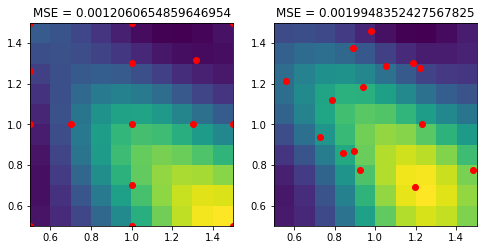

In [11]:
fig, axs = plt.subplots(1, 2, figsize=(8, 4))
ax = axs.ravel()

# MSE of a GP after using bayes optimization to minimize uncertainty
mu, cov = bayes._gp.predict(X=X_test, return_cov=True)
mse = mean_squared_error(mu, y_true)
axs[0].imshow(mu.reshape(res, res), origin='upper', extent=[0.5, 1.5, 0.5, 1.5])
axs[0].set_title("MSE = {}".format(mse))
axs[0].plot(bayes.param_samples[:, 0], bayes.param_samples[:, 1], "r.", ms=12)

# MSE of a GP after training it on randomly selected datapoints
np.random.seed(123)
nu_a_random = np.random.uniform(0.5, 1.5, 15)
np.random.seed(1234)
nu_j_random = np.random.uniform(0.5, 1.5, 15)
X_random = np.vstack((nu_a_random, nu_j_random)).T
y_random = np.array([Eff_MET10_sigmoid(X_random[i][0], X_random[i][1]) for i in range(len(X_random))])
dy_random = np.array([dEff_MET10_sigmoid(X_random[i][0], X_random[i][1]) for i in range(len(X_random))])
kernel = GPKernel()
gp = GaussianProcessRegressor(kernel=kernel,
                              n_restarts_optimizer=10, 
                              random_state=123)
gp.fit(X=X_random, y=y_random)
mu, cov = gp.predict(X=X_test, return_cov=True)
mse = mean_squared_error(mu, y_true)
axs[1].imshow(mu.reshape(res, res), origin='upper', extent=[0.5, 1.5, 0.5, 1.5])
axs[1].set_title("MSE = {}".format(mse))
axs[1].plot(X_random[:, 0], X_random[:, 1], "r.", ms=12)
plt.show()

(2) With derivatives

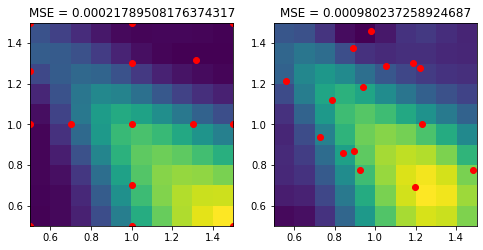

In [12]:
fig, axs = plt.subplots(1, 2, figsize=(8, 4))
ax = axs.ravel()

# MSE of a GP after using bayes optimization to minimize uncertainty
mu, cov = bayes_der._gp.predict(X=X_test, return_cov=True)
mse = mean_squared_error(mu, y_true)
axs[0].imshow(mu.reshape(res, res), origin='upper', extent=[0.5, 1.5, 0.5, 1.5])
axs[0].set_title("MSE = {}".format(mse))
axs[0].plot(bayes.param_samples[:, 0], bayes.param_samples[:, 1], "r.", ms=12)

# MSE of a GP after training it on randomly selected datapoints
np.random.seed(123)
nu_a_random = np.random.uniform(0.5, 1.5, 15)
np.random.seed(1234)
nu_j_random = np.random.uniform(0.5, 1.5, 15)
X_random = np.vstack((nu_a_random, nu_j_random)).T
y_random = np.array([Eff_MET10_sigmoid(X_random[i][0], X_random[i][1]) for i in range(len(X_random))])
dy_random = np.array([dEff_MET10_sigmoid(X_random[i][0], X_random[i][1]) for i in range(len(X_random))])
kernel = GPKernelDerAware()
gp = GaussianProcessRegressor(kernel=kernel,
                              n_restarts_optimizer=10, 
                              random_state=123)
gp.fit(X=X_random, y=y_random, dy=dy_random)
mu, cov = gp.predict(X=X_test, return_cov=True)
mse = mean_squared_error(mu, y_true)
axs[1].imshow(mu.reshape(res, res), origin='upper', extent=[0.5, 1.5, 0.5, 1.5])
axs[1].set_title("MSE = {}".format(mse))
axs[1].plot(X_random[:, 0], X_random[:, 1], "r.", ms=12)
plt.show()